In [1]:
import numpy as np
import pandas as pd
import glob
import os
import sys
import matplotlib.pyplot as plt
import torch
import matplotlib.gridspec as gridspec
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

Issue ! Reampling causes data magnitude to shift.#resampler.SetInterpolator(sitk.sitkLinear) ===> Solution: use Nearest Neighbor (sitk.sitkNearestNeighbor): This method assigns the value of the nearest neighboring voxel to the resampled point. It does not perform any interpolation and is suitable when you want to preserve the original data values without smoothing.

In [15]:
def plot_data(dose): #plot with shape zyx 126*256*256

    VOXELNUMBER_X = dose.shape[2]
    VOXELNUMBER_Y = dose.shape[1]
    VOXELNUMBER_Z = dose.shape[0]

    x_vals = np.arange(0, VOXELNUMBER_X, 1)
    y_vals =  np.arange(0, VOXELNUMBER_Y, 1)
    z_vals =  np.arange(0, VOXELNUMBER_Z, 1)

    max_index = np.unravel_index(dose.argmax(), dose.shape)
    print('max_index',max_index)
    dose_x = []
    dose_y = []
    dose_z = []
    for x in range(VOXELNUMBER_X):
        dose_x.append(dose[int(max_index[0]), int(max_index[1]),x])        
    for y in range(VOXELNUMBER_Y):
        dose_y.append(dose[int(max_index[0]),y,int(max_index[2])])
    for z in range(VOXELNUMBER_Z):        
        dose_z.append(dose[z, int(max_index[1]),int(max_index[2])])

    # Create a 2x3 grid of subplots

    fig = plt.figure(figsize=(8, 3))
    gs = gridspec.GridSpec(1, 3, width_ratios=[0.7, 0.7, 1])  # 3 plots
    ax2 = plt.subplot(gs[2])
    ax2.plot(x_vals, dose_x)
    ax2.set_yscale('linear')
    ax2.set_xlabel('X voxel number (Beam direction)')

    ax1 = plt.subplot(gs[1])
    ax1.plot(y_vals, dose_y)
    ax1.set_yscale('linear')
    ax1.set_xlabel('Y  voxel number')


    ax0 = plt.subplot(gs[0])
    ax0.plot(z_vals, dose_z)
    ax0.set_yscale('linear')
    ax0.set_xlabel('Z  voxel number')
    ax0.set_ylabel('Dose [Gy]')
    ax0.set_title('Dose in head phantom at beam center')
    
    plt.tight_layout()
    plt.show()  

max_index (44, 146, 173)


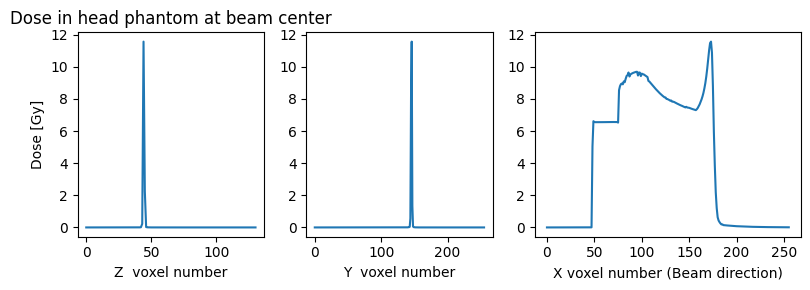

In [16]:
filepath =  "/scratch/tappay01/data/data5/Data5_1750MeV_25Mm_-96.5Mm.npy"
filename = 'Data5_2750MeV_25Mm_-96.5Mm.npy'

dose = np.load(filepath)
plot_data(dose)

11.5737
max_index (7, 8, 112)


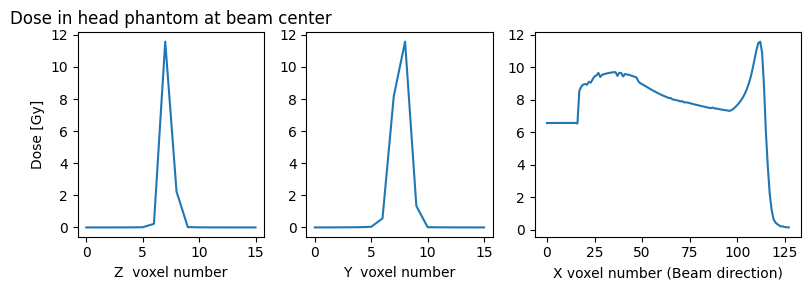

In [17]:
filepath_resampled = "/scratch/tappay01/data/data5_resampled/Data5_1750MeV_25Mm_-96.5Mm.npy"

dose_saved = np.load(filepath_resampled)
print(np.max(dose_saved))
plot_data(dose_saved)

12.1499
max_index (8, 8, 89)


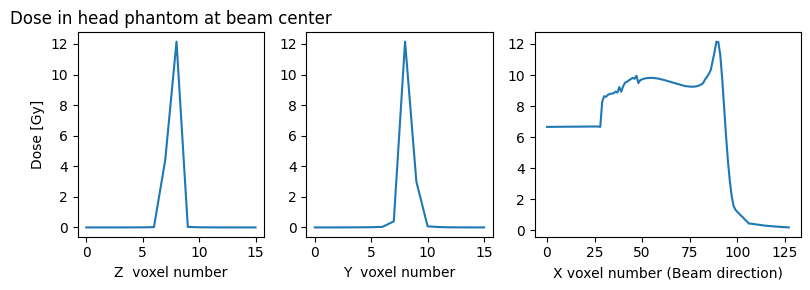

In [22]:
filepath7 = "/scratch/tappay01/data/data7_resampled/Data7_1750MeV_-25Mm_-96.5Mm.npy"
dose_saved = np.load(filepath7)
print(np.max(dose_saved))
plot_data(dose_saved)

11.9175
max_index (7, 8, 101)


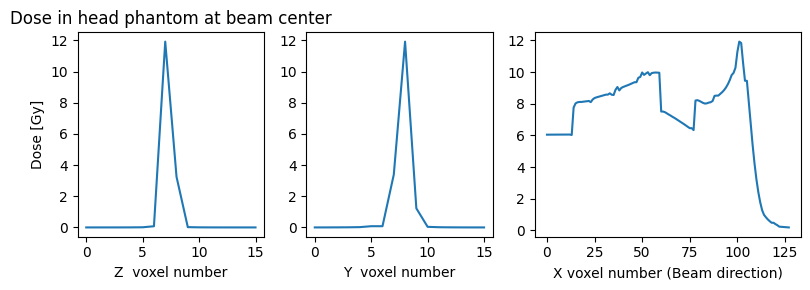

In [23]:
filepath2 = "/scratch/tappay01/data/data2_resampled/Data2_1750MeV_75Mm_-71.5Mm.npy"
dose_saved = np.load(filepath2)
print(np.max(dose_saved))
plot_data(dose_saved)

5.65624
max_index (8, 8, 95)


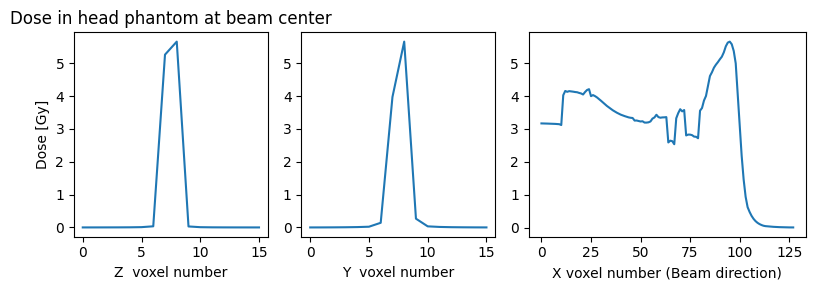

In [24]:
filepath1 = "/scratch/tappay01/data/data1_resampled/Data1_1750MeV_75Mm_-71.5Mm.npy"
dose_saved = np.load(filepath1)
print(np.max(dose_saved))
plot_data(dose_saved)

Data5
(1.378906, 1.378906, 2.5) (-176.5, -176.5, -208.25)
max_index (44, 146, 86)


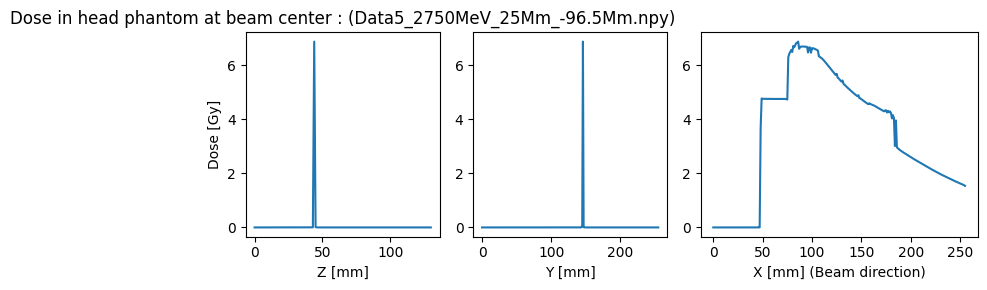

In [54]:
# xzy
datasets = {
    "Data1": {
        "voxel_dim": [0.707031*2, 0.707031*2, 1.25*2],
        "origin": [-181, -181, -229],
        "positions_x": [-110],
        "positions_y": [-50, -25, 0, 25, 50, 75],
        "positions_z": [-146.5, -121.5, -96.5, -71.5, -46.5],
        "voxel_center": [0,0,-71.5]
    },
    "Data2": {
        "voxel_dim": [0.759766*2, 0.759766*2, 1.25*2],
        "origin": [-194.5, -194.5, -271],
        "positions_x": [-110],
        "positions_y": [-25, 0, 25, 50, 75],
        "positions_z": [-171.5, -146.5, -121.5, -96.5, -71.5],
        "voxel_center": [0,0,-72.25]
    },
    "Data4": {
        "voxel_dim": [0.666016*2, 0.666016*2, 1.25*2],
        "origin": [-170.5,-170.5, -188.75],
        "positions_x": [-110],
        "positions_y": [-50, -25, 0, 25, 50, 75],
        "positions_z": [-71.5, -46.5, -21.5, 3.5],
        "voxel_center": [0,0,-32.5]
    },
    "Data5": {
        "voxel_dim": [0.689453*2, 0.689453*2, 1.25*2],
        "origin": [-176.5, -176.5, -208.25],
        "positions_x": [-110],
        "positions_y": [-50, -25, 0, 25, 50, 75],
        "positions_z": [-96.5, -71.5, -46.5, -21.5],
        "voxel_center": [0,0,-44.5]
    },
    "Data7": {
        "voxel_dim": [0.683594*2, 0.683594*2, 1.25*2],
        "origin": [-175, -175, -199.25],
        "positions_x": [-110],
        "positions_y": [-25, 0, 25, 50, 75],
        "positions_z": [-96.5, -71.5, -46.5, -21.5],
        "voxel_center": [0,0,-29.25]
    }
}

import SimpleITK as sitk
import os
import numpy as np
import glob


def set_sitk_image(array, dataset):
    # Convert numpy array to SimpleITK image
    sitk_image = sitk.GetImageFromArray(array)  
    # Set the spacing for data
    spacing = datasets[dataset]["voxel_dim"]
    sitk_image.SetSpacing(spacing) #xyz
    origin = datasets[dataset]["origin"]
    sitk_image.SetOrigin(origin)
    print(sitk_image.GetSpacing(),sitk_image.GetOrigin() )
    return sitk_image

    
def resample_image(input_image, new_spacing, new_origin):
    size = input_image.GetSize()
    spacing = input_image.GetSpacing()
    new_size = [int(size[d] * spacing[d] / new_spacing[d]) for d in range(3)]
    resampler = sitk.ResampleImageFilter()
    resampler.SetSize(new_size)
    resampler.SetOutputSpacing(new_spacing)
    resampler.SetOutputOrigin(new_origin)
    resampler.SetOutputDirection(input_image.GetDirection())
    #resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetInterpolator(sitk.sitkNearestNeighbor)

    resampled_image = resampler.Execute(input_image)
    return resampled_image

def extract_from_filename(filename, param):
    """Extracts energy value from the given filename."""
    parts = filename.split('_')
    if param == 'y':
        return float(parts[2][:-2])
    if param == 'z':
        return float(parts[3][:-6])
    if param == 'energy':
        return parts[1]
    else:
        return None

# function to extract ROI and convert to numpy
def extract_roi_array(image, roi_size, center_physical):
    source_index = image.TransformPhysicalPointToIndex(center_physical)
    print('source index y,z',source_index[1], source_index[2] )
    start_index = [int(source_index[0]-roi_size[0]*0.5), int(source_index[1]-roi_size[1]*0.5), int(source_index[2]-roi_size[2]*0.5)]
    print('start_index' , start_index)
    roi = sitk.RegionOfInterest(image, roi_size, start_index)
    return sitk.GetArrayFromImage(roi) 


dataset = filename.split('_')[0]
print(dataset)

# target = data1
target_spacing = datasets["Data1"]["voxel_dim"]
target_origin = datasets["Data1"]["origin"]
roi_size = (128,16,16) #xyz  
# center_physical = datasets["data1"]["voxel_center"] for full size

# Load data from .npy
array = np.load(filepath)
# Convert numpy array to SimpleITK image and set parameters
image = set_sitk_image(array, dataset)
resampled_array = sitk.GetArrayFromImage(image) 
plot_data(resampled_array)


max_index (52, 146, 87)


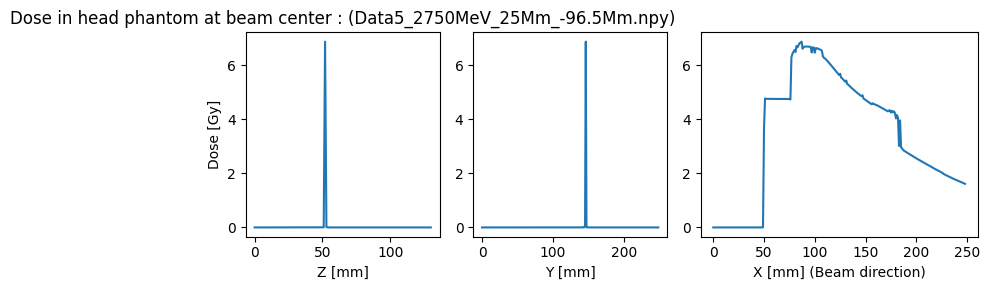

(131, 249, 249)


In [55]:
if dataset != 'Data1':
    # Resample the image
    resampled = resample_image(image, target_spacing, target_origin)
if dataset == 'Data1':
    resampled = image

resampled_array = sitk.GetArrayFromImage(resampled) 
plot_data(resampled_array)

print(resampled_array.shape)

source index y,z 146 53
start_index [60, 138, 45]
(16, 16, 128)
6.88425
max_index (7, 8, 27)


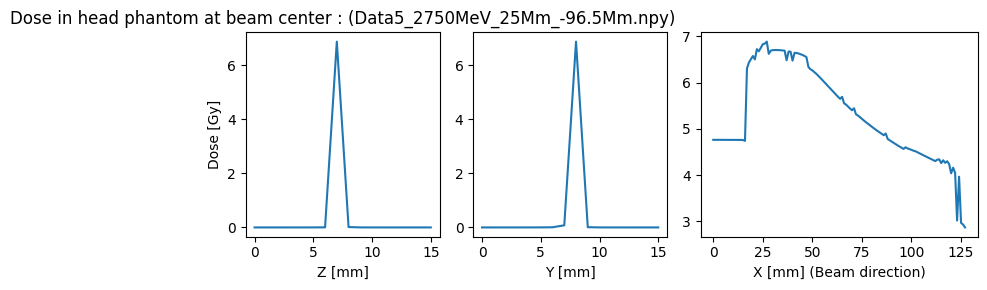

In [56]:
# Extract ROI    
# y z source position extract from file name
# source at x postion = -110, but use -5 to crop from this point as center, which is index 124. 
# We want to crop X range size 128 from index 60 to 188 to cover the head.
source_physical = [-5, extract_from_filename(filename,'y'), extract_from_filename(filename,'z')]
roi_array = extract_roi_array(resampled, roi_size, source_physical)
print(roi_array.shape)
print(np.max(roi_array))
plot_data(roi_array)

In [57]:
import torch
import matplotlib.pyplot as plt
def plot_slice(dose):
    data_sample = dose
    # Define the figure and the grid
    fig = plt.figure(figsize=(15, 3))
    gs = gridspec.GridSpec(1, 4, width_ratios=[1, 2, 2, 0.2])  # 3 plots + 1 colorbar
    max_index = np.unravel_index(data_sample.argmax(), data_sample.shape)
    print(max_index)    
    # ZY plane
    ax0 = plt.subplot(gs[0])
    #ax0.imshow(density_sample[:, :, max_index[2]], cmap='gray')
    ax0.imshow(data_sample[:, :,max_index[2]], cmap='inferno', alpha=0.7)
    ax0.set_title("ZY Plane")
    ax0.set_xlabel('Z voxel number')
    ax0.set_ylabel('Y voxel number')

    # ZX plane
    ax1 = plt.subplot(gs[1])
    #ax1.imshow(density_sample[:, max_index[1], :], cmap='gray')
    ax1.imshow(data_sample[:, max_index[1], :], cmap='inferno', alpha=0.7)
    ax1.set_xlabel('X voxel number')
    ax1.set_ylabel('Z voxel number')

    # YX plane
    ax2 = plt.subplot(gs[2])
    #ax2.imshow(density_sample[max_index[0], :, :], cmap='gray')
    img_data = ax2.imshow(data_sample[max_index[0], :, :], cmap='inferno', alpha=0.7)
    ax2.set_xlabel('X voxel number')
    ax2.set_ylabel('Y voxel number')

    # Colorbar
    cax = plt.subplot(gs[3])
    cbar = plt.colorbar(img_data, cax=cax)
    cbar.set_label('dose / dose_max')

    plt.tight_layout()
    plt.show()

    '''
    water_sample = water_batch[i, 0]
    # Define the figure and the grid
    fig = plt.figure(figsize=(15, 3))
    gs = gridspec.GridSpec(1, 4, width_ratios=[1, 2, 2, 0.2])  # 3 plots + 1 colorbar
    max_index = np.unravel_index(water_sample.argmax(), water_sample.shape)
    print(max_index)
        
    # ZY plane
    ax0 = plt.subplot(gs[0])
    ax0.imshow(water_sample[:, :,max_index[2]], cmap='inferno', alpha=1)
    ax0.set_title("ZY Plane")
    ax0.set_xlabel('Z voxel number')
    ax0.set_ylabel('Y voxel number')

    # ZX plane
    ax1 = plt.subplot(gs[1])
    ax1.imshow(water_sample[:, max_index[1], :], cmap='inferno', alpha=1)
    ax1.set_title('Dose in water phantom')
    ax1.set_xlabel('X voxel number')
    ax1.set_ylabel('Z voxel number')

    # YX plane
    ax2 = plt.subplot(gs[2])
    img_water = ax2.imshow(water_sample[max_index[0], :, :], cmap='inferno', alpha=1)
    ax2.set_xlabel('X voxel number')
    ax2.set_ylabel('Y voxel number')

    # Colorbar
    cax = plt.subplot(gs[3])
    cbar = plt.colorbar(img_water, cax=cax)
    cbar.set_label('dose / dose_max')

    plt.tight_layout()
    plt.show()
    #plt.savefig(f'sample_{i+1}.png')  # Save each sample's image to a file
    #plt.close(fig)  # Close the figure to free up memory

    # images named sample_1.png, sample_2.png, ... saved in the current directory.
    '''

(7, 8, 27)


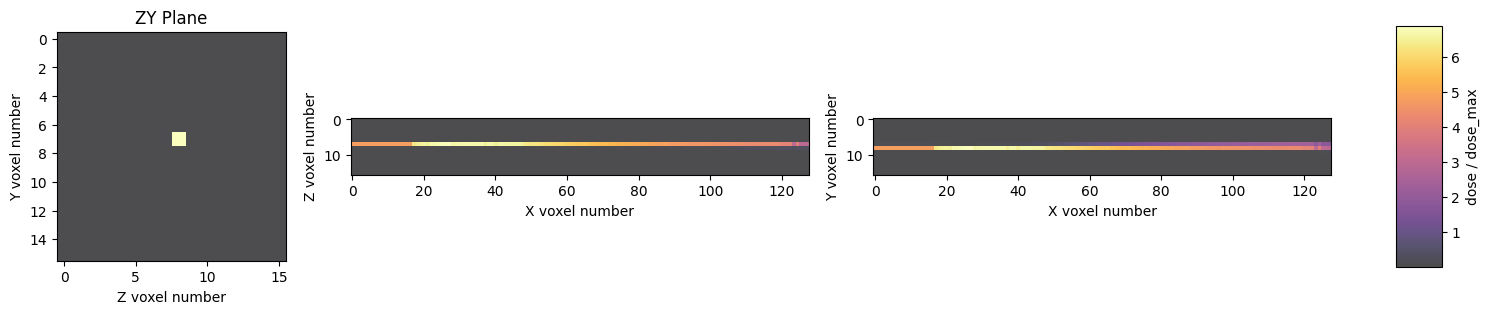

In [58]:
plot_slice(roi_array)

(7, 8, 27)


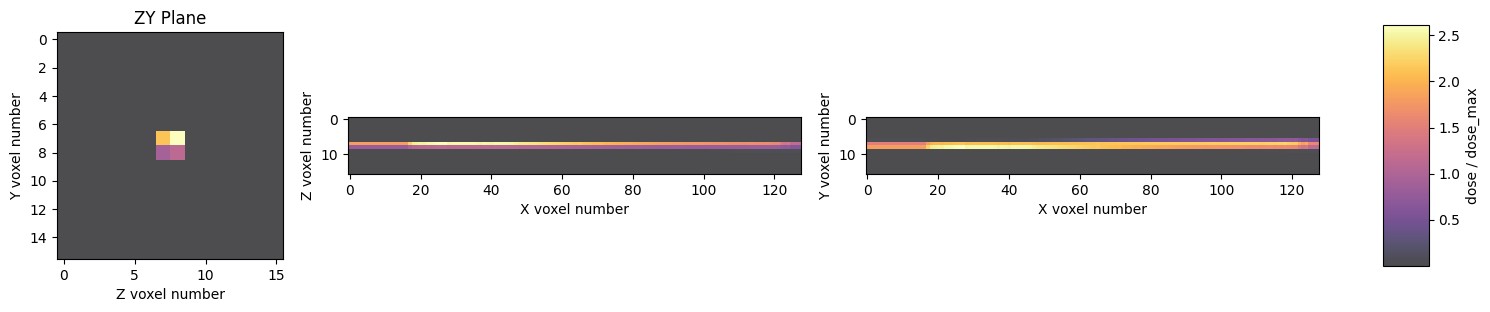

In [60]:
plot_slice(dose_saved)